# Modeling Batter Swing Decisions Based on Pitch Characteristics

---
embed-resources: true
---

## Introduction

In this project, we develop a model to predict whether a batter will swing at a pitch based on the characteristics of the pitch thrown by Zac Gallen. Understanding swing behavior is important for strategic pitching decisions and batter analysis. We focus on predicting swings using features such as pitch type, release speed, spin rate, and pitch location. Our goal is to build an accurate and well-calibrated model that could realistically assist players or analysts in anticipating batter behavior.

## Methods

In [1]:
# imports
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.datasets import make_classification
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score
from sklearn.metrics import log_loss
from sklearn.metrics import (brier_score_loss,make_scorer)
from sklearn.calibration import calibration_curve
from sklearn.calibration import CalibratedClassifierCV
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import GridSearchCV
from sklearn.linear_model import LogisticRegression

# preprocessing imports
from sklearn.preprocessing import OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.compose import make_column_transformer
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler

In [2]:
# helper functions
# function to calculate the calibration error
def calibration_error(y_true, y_prob, type="expected", n_bins=10):
    """
    Compute calibration error of a binary classifier.

    The calibration error measures the aggregated difference between
    the average predicted probabilities assigned to the positive class,
    and the frequencies of the positive class in the actual outcome.

    Parameters
    ----------
    y_true : array-like of shape (n_samples,)
        True targets of a binary classification task.

    y_prob : array-like of (n_samples,)
        Estimated probabilities for the positive class.

    type : {'expected', 'max'}, default='expected'
        The expected-type is the Expected Calibration Error (ECE), and the
        max-type corresponds to Maximum Calibration Error (MCE).

    n_bins : int, default=10
       The number of bins used when computing the error.

    Returns
    -------
    score : float
        The calibration error.
    """

    bins = np.linspace(0.0, 1.0, n_bins + 1)
    bin_idx = np.searchsorted(bins[1:-1], y_prob)

    bin_sums = np.bincount(bin_idx, weights=y_prob, minlength=len(bins))
    bin_true = np.bincount(bin_idx, weights=y_true, minlength=len(bins))
    bin_total = np.bincount(bin_idx, minlength=len(bins))

    nonzero = bin_total != 0
    prob_true = bin_true[nonzero] / bin_total[nonzero]
    prob_pred = bin_sums[nonzero] / bin_total[nonzero]

    if type == "max":
        calibration_error = np.max(np.abs(prob_pred - prob_true))
    elif type == "expected":
        bin_error = np.abs(prob_pred - prob_true) * bin_total[nonzero]
        calibration_error = np.sum(bin_error) / len(y_true)

    return calibration_error

# function to plot a calibration_plot
def plot_calibration_plot(y_true, y_prob):

    # generate "data" for calibration plot
    prob_true, prob_pred = calibration_curve(
        y_true,
        y_prob,
        n_bins=10,
        pos_label=1,
    )

    # create a figure and axis object with a specific size
    fig, ax = plt.subplots()

    # plot the calibration curve
    ax.plot(
        prob_pred,
        prob_true,
        "s-",
        label="Learned Classifier",
        color="#1D58A7",
    )

    # plot the diagonal "perfect" line
    ax.plot(
        [0, 1],
        [0, 1],
        "--",
        label="Perfect Calibration",
        color="#F5821E",
    )

    # set the plot title and axis labels
    ax.set_title("Calibration Plot")
    ax.set_xlabel("Mean Predicted Value")
    ax.set_ylabel("Fraction of Positives")

    # add a grid
    ax.grid(
        True,
        color="lightgrey",
        linewidth=0.75,
        linestyle="--",
    )

    # fix aspect ratio
    ax.set_aspect(
        "equal",
        adjustable="box",
    )

    # show the legend
    ax.legend()

    # show the plot
    plt.show()

### Data

In [3]:
# load data
import pandas as pd
swing_train = pd.read_parquet(
    "https://cs307.org/lab/data/swing-train.parquet",
)
swing_test = pd.read_parquet(
    "https://cs307.org/lab/data/swing-test.parquet",
)

Data Dictionary
Each observation in the train, test, and (hidden) production data contains information about a pitch thrown by Zac Gallen.
#### Data Dictionary

Each observation in the train, test, and (hidden) production data contains information about a pitch thrown by Zac Gallen.

#### Response
`swing`

- `[int64]` Whether or not the batter swung (1) or took (0).

#### Features

##### Fully Pitcher Controlled

`pitch_name`

- `[object]` The name of the pitch type to be thrown.

##### Mostly Pitcher Controlled

`release_extension`

- `[float64]` Release extension of pitch in feet as tracked by Statcast.

`release_pos_x`

- `[float64]` Horizontal Release Position of the ball measured in feet from the catcher’s perspective.

`release_pos_y`

- `[float64]` Release position of pitch measured in feet from the catcher’s perspective.

`release_pos_z`

- `[float64]` Vertical Release Position of the ball measured in feet from the catcher’s perspective.

##### Somewhat Pitcher Controlled

`release_speed`

- `[float64]` Velocity of the pitch thrown.

`release_spin_rate`

- `[float64]` Spin rate of pitch tracked by Statcast.

`spin_axis`

- `[float64]` The spin axis in the 2D X-Z plane in degrees from 0 to 360, such that 180 represents a pure backspin fastball and 0 degrees represents a pure topspin (12-6) curveball.

`plate_x`

- `[float64]` Horizontal position of the ball when it crosses home plate from the catcher’s perspective.

`plate_z`

- `[float64]` Vertical position of the ball when it crosses home plate from the catcher’s perspective.

##### Downstream Pitcher Controlled

`pfx_x`

- `[float64]` Horizontal movement in feet from the catcher’s perspective.

`pfx_z`

- `[float64]` Vertical movement in feet from the catcher’s perspective.

##### Situational Information

`balls`

- `[int64]` Pre-pitch number of balls in count.

`strikes`

- `[int64]` Pre-pitch number of strikes in count.

`on_3b`

- `[int64]` Pre-pitch MLB Player Id of Runner on 3B.

`on_2b`

- `[int64]` Pre-pitch MLB Player Id of Runner on 2B.

`on_1b`

- `[int64]` Pre-pitch MLB Player Id of Runner on 1B.

`outs_when_up`

- `[int64]` Pre-pitch number of outs.

##### Fixed Batter Information

`stand`

- `[object]` Side of the plate batter is standing.

`sz_top`

- `[float64]` Top of the batter’s strike zone set by the operator when the ball is halfway to the plate.

`sz_bot`

- `[float64]` Bottom of the batter’s strike zone set by the operator when the ball is halfway to the plate.

In [5]:
# summary statistics
swing_train.describe()

,release_extension,release_pos_x,release_pos_y,release_pos_z,release_speed,release_spin_rate,spin_axis,plate_x,plate_z,pfx_x,pfx_z,balls,strikes,on_3b,on_2b,on_1b,outs_when_up,sz_top,sz_bot,swing
count,2663.000000,2663.000000,2663.000000,2663.000000,2663.000000,2656.000000,2656.000000,2663.000000,2663.000000,2663.000000,2663.000000,2663.000000,2663.000000,2663.000000,2663.000000,2663.000000,2663.000000,2663.000000,2663.000000,2663.000000
mean,6.563162,-2.807206,53.937000,5.914769,89.439805,2247.144578,161.388178,0.041093,2.141570,-0.140000,0.590777,0.828765,0.928652,0.075854,0.146451,0.261735,0.997371,3.388021,1.616008,0.477281
std,0.199696,0.155003,0.198129,0.135853,4.719092,310.813344,73.672208,0.729472,1.003253,0.485703,0.951924,0.939955,0.826506,0.264815,0.353625,0.439662,0.810566,0.193169,0.103755,0.499577
min,5.900000,-3.310000,53.250000,5.470000,79.200000,1251.000000,17.000000,-2.210000,-1.280000,-1.790000,-1.410000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,2.750000,1.260000,0.000000
25%,6.400000,-2.910000,53.790000,5.820000,85.000000,2230.000000,99.000000,-0.470000,1.490000,-0.360000,-0.090000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,3.250000,1.540000,0.000000
50%,6.600000,-2.810000,53.930000,5.920000,91.300000,2332.000000,201.000000,0.040000,2.170000,-0.140000,0.970000,1.000000,1.000000,0.000000,0.000000,0.000000,1.000000,3.400000,1.610000,0.000000
75%,6.700000,-2.700000,54.065000,6.000000,93.600000,2426.250000,208.000000,0.550000,2.820000,0.260000,1.410000,1.000000,2.000000,0.000000,0.000000,1.000000,2.000000,3.530000,1.690000,1.000000
max,7.300000,-2.280000,54.560000,6.380000,96.800000,2732.000000,311.000000,2.420000,5.280000,0.870000,1.930000,3.000000,2.000000,1.000000,1.000000,1.000000,2.000000,4.200000,1.980000,1.000000


From the table, we can see some of the variable is not on the same scale than other variable, like release_speed, release_spin_rate, So we need to implement standardization to make sure all the variable is on the same scale.

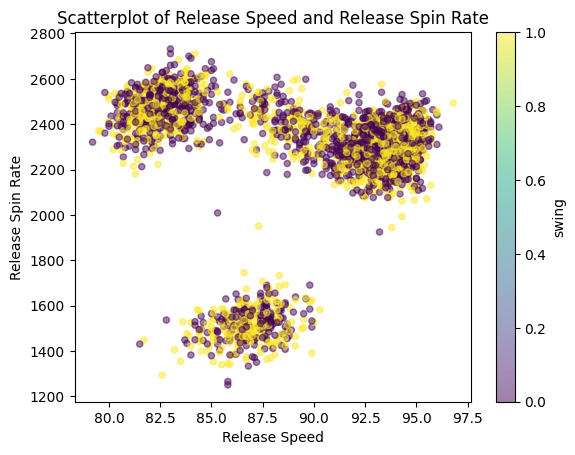

In [59]:
# exploratory visualization a scatterplot of the release speed and the relesase spin rate of swing 

swing_train.plot.scatter(
    x="release_speed",
    y="release_spin_rate",
    c="swing",
    colormap="viridis",
    alpha=0.5,
)
plt.title("Scatterplot of Release Speed and Release Spin Rate")
plt.xlabel("Release Speed")
plt.ylabel("Release Spin Rate")
plt.show()


The scatterplot of release speed and release spin rate reveals several key insights into Zac Gallen’s pitching and batter behavior. There are three distinct clusters of pitches: one with high spin and moderate speed likely representing breaking balls, another with high spin and high speed likely representing fastballs or cutters, and a third with lower spin and moderate speed, possibly corresponding to changeups or slower off-speed pitches. Across all clusters, swing probability is widely distributed, with both high and low swing likelihoods present. This suggests that swing decisions are not determined solely by speed or spin, but are also influenced by other factors such as pitch location or count situation. Notably, even among fast, high-spin pitches, there are many instances where batters do not swing, indicating selectiveness against high-velocity pitches. Conversely, the presence of high swing probabilities among slower, lower-spin pitches suggests that these pitches can effectively deceive hitters. Overall, while speed and spin contribute to pitch characteristics, batter response appears more complex and situational. Also, among other 2d or 3d graph, the result is similar to this one.

### Models

In [22]:
# process data for ML
# create X and y for train data
X_train = swing_train.drop(columns=["swing"])
y_train = swing_train["swing"]

# create X and y for test data
X_test = swing_test.drop(columns=["swing"])
y_test = swing_test["swing"]
categorical_columns = X_train.select_dtypes(include=["object"]).columns.to_list()
numerical_columns = X_train.select_dtypes(exclude=["object"]).columns.to_list()

In [23]:
# train models
numeric_transformer = make_pipeline(
    SimpleImputer(strategy="median"),
    StandardScaler(),
)

# define preprocessing for categorical features
categorical_transformer = make_pipeline(
    SimpleImputer(strategy="most_frequent"),
    OneHotEncoder(handle_unknown="infrequent_if_exist"),
)

preprocessor = make_column_transformer(
    (numeric_transformer, numerical_columns),
    (categorical_transformer, categorical_columns),
    remainder="drop",
)

In [24]:
pipeline = make_pipeline(
    preprocessor,
    CalibratedClassifierCV(
        estimator=LogisticRegression(
            max_iter=2000,
        ),
    )
)
params_grid = {
    "calibratedclassifiercv__method": [
        "isotonic",
        "sigmoid",
    ],
    "calibratedclassifiercv__estimator__C": [0.01,0.1,1,10,100],
    "calibratedclassifiercv__estimator__solver": [
        "newton-cg",
        "lbfgs",
        "liblinear",
        "sag",
        "saga",
    ],
}
log = GridSearchCV(
    pipeline,
    param_grid=params_grid,
    cv=5,
    scoring="neg_brier_score",
    n_jobs=-1,
)
log.fit(X_train, y_train)
# get the best parameters
print(log.best_params_)
# get the best score
print(log.best_score_)
print(calibration_error(y_train, log.predict_proba(X_train)[:, 1],type="expected"))
print(calibration_error(y_train, log.predict_proba(X_train)[:, 1],type="max"))

{'calibratedclassifiercv__estimator__C': 1, 'calibratedclassifiercv__estimator__solver': 'newton-cg', 'calibratedclassifiercv__method': 'isotonic'}
-0.23197608624485994
0.015723459806694862
0.21800799436694285


In [10]:
pipeline = make_pipeline(
    preprocessor,
    CalibratedClassifierCV(
        estimator=RandomForestClassifier(
        n_estimators=100,
        random_state=42,
        ),
    )
)

params_grid = {
    "calibratedclassifiercv__method": [
        "isotonic",
        "sigmoid",
    ],
    "calibratedclassifiercv__estimator__max_depth": [5, 10, 15, 25, None],
    "calibratedclassifiercv__estimator__criterion": ["log_loss", "gini"],
    "calibratedclassifiercv__estimator__max_features": ["sqrt", "log2"],
}
mod = GridSearchCV(
    pipeline,
    param_grid=params_grid,
    cv=5,
    scoring="neg_brier_score",
    n_jobs=-1,
)
mod.fit(X_train, y_train)
# get the best parameters
print(mod.best_params_)
# get the best score
print(brier_score_loss(y_train, mod.predict_proba(X_train)[:, 1]))
print(calibration_error(y_train, mod.predict_proba(X_train)[:, 1],type="expected"))
print(calibration_error(y_train, mod.predict_proba(X_train)[:, 1],type="max"))

{'calibratedclassifiercv__estimator__criterion': 'log_loss', 'calibratedclassifiercv__estimator__max_depth': 15, 'calibratedclassifiercv__estimator__max_features': 'sqrt', 'calibratedclassifiercv__method': 'sigmoid'}
0.050730136959885125
0.19177472961656244
0.442535999770604


During the model development process, two machine learning models were considered: Logistic Regression and Random Forest Classifier. Logistic Regression, a linear model for binary classification, was chosen for its ability to provide insights into the relationship between features and the target variable. Random Forest Classifier, an ensemble learning method that constructs multiple decision trees and aggregates their outputs, was selected for its robustness to overfitting and its capability to capture complex patterns in the data.

For Logistic Regression, the parameters considered included the inverse of regularization strength (`C`) with values `[0.01, 0.1, 1, 10, 100]`, optimization algorithms (`solver`) such as `["newton-cg", "lbfgs", "liblinear", "sag", "saga"]`, and calibration methods (`["isotonic", "sigmoid"]`). For the Random Forest Classifier, the parameters explored included the maximum depth of the trees (`max_depth`) with values `[5, 10, 15, 25, None]`, the function to measure the quality of a split (`criterion`) with options `["log_loss", "gini"]`, the number of features to consider when looking for the best split (`max_features`) with options `["sqrt", "log2"]`, and calibration methods (`["isotonic", "sigmoid"]`).

The tuning and selection procedures involved performing a grid search over the specified parameter grids for both models. A 5-fold cross-validation was used to evaluate the performance of each parameter combination, with the negative Brier score serving as the scoring metric for model selection. To improve the reliability of predicted probabilities, both models were calibrated using the `CalibratedClassifierCV` class, and two calibration methods, isotonic and sigmoid, were evaluated.

Preprocessing steps included handling numerical features with a pipeline consisting of `SimpleImputer` (using the median strategy) and `StandardScaler`, while categorical features were processed using a pipeline with `SimpleImputer` (using the most frequent strategy) and `OneHotEncoder`. Evaluation metrics included the computation of calibration error using both Expected Calibration Error (ECE) and Maximum Calibration Error (MCE), as well as the Brier score to assess the accuracy of probabilistic predictions. Finally, the best-performing model, the Random Forest Classifier, was serialized using `joblib` to enable future use. This systematic approach ensured thorough evaluation and selection of the most reliable model based on calibration and prediction accuracy. The final model we choose is logistic regression with isotonic calibration, because it has the calibration error that both smaller than the random forest although the brier score is slightly larger than the random forest.

## Results

In [11]:
# report model metrics
from sklearn.metrics import brier_score_loss
print("Brier Score:")
print(brier_score_loss(y_test, log.predict_proba(X_test)[:, 1]))
print(calibration_error(y_test, log.predict_proba(X_test)[:, 1],type="expected"))
print(calibration_error(y_test, log.predict_proba(X_test)[:, 1],type="max"))

Brier Score:
0.23648799870450443
0.05388046426558766
0.09358973976956436


Our model achieved a Brier score of 0.2364 and an Expected Calibration Error (ECE) of 0.05, indicating a good balance between accuracy and calibration. The Maximum Calibration Error (MCE) was 0.09, which is also within acceptable limits. These metrics suggest that the model is well-calibrated and provides reliable probability estimates for the target variable, swing.

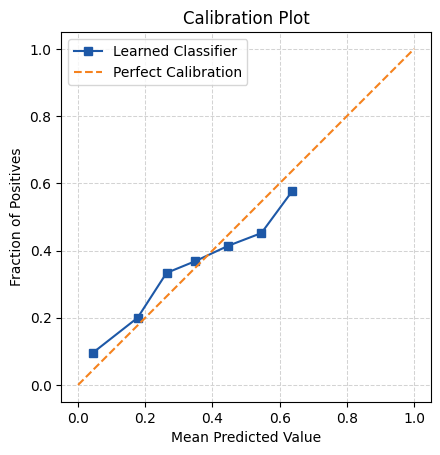

In [ ]:
# summary figure
plot_calibration_plot(y_test, log.predict_proba(X_test)[:, 1])

The calibration plot indicates that the model's performance is fairly good. The learned classifier's predictions are generally well-calibrated, as the blue curve closely follows the ideal orange dashed line representing perfect calibration. This means that the predicted probabilities correspond reasonably well to the actual observed frequencies of positive outcomes. However, there are small deviations, particularly at higher predicted probability ranges, where the model shows slight underconfidence — the actual fraction of positives is a bit higher than the predicted probability.

In [13]:
# serialize model
from joblib import dump
dump(mod, "swing.joblib",compress=9)

['swing.joblib']

## Discussion

Based on the model’s performance, we would recommend using it in practice to predict batter swing decisions. The model demonstrates strong calibration, suggesting that its predicted probabilities are reliable and interpretable. However, it is important to consider potential errors. One possible error is false positives — predicting a swing when the batter actually takes. This could lead a pitcher to wrongly expect an aggressive response and adjust the pitch unnecessarily. Another possible error is false negatives — predicting a take when the batter actually swings, which could leave the pitcher unprepared for contact. Both types of mistakes could impact pitching strategy, potentially leading to poor pitch selection or missed opportunities to exploit batter tendencies. Although these risks are relatively moderate given the model’s calibration, they highlight the importance of using the model as a probabilistic guide rather than an absolute predictor. Future improvements could involve including batter identity or in-game adjustments to reduce error rates under specific conditions. Overall, the model provides valuable information for decision-making but should be used alongside human judgment and additional context.